<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%208/W08_L3_Beyond_Captioning_VQA_and_Dialog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=bxYkGKSCTlA) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%208/NPTEL_Jul24_DL4CV_W08_P03.pdf)

In [1]:
# Week 8, Lecture 3: Beyond Captioning : VQA and Dialog
from IPython.display import HTML, display

VIDEO_ID = "bxYkGKSCTlA"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 8, Lecture 3: Going beyond Captioning — Visual QA and Visual Dialog

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§8.3 Visual QA and Dialog**.

**What you will learn**

- The VQA task, and the four datasets the slides survey, with their numbers.
- Four ways to fuse an image with a question — and the parameter cost of each, which is what decides the field.
- **Stacked Attention Networks**: attending twice, refining the query in between.
- **Hierarchical co-attention**: attending to the question as well as the image.
- **Visual Dialog**, and why it is evaluated by *ranking 100 candidate answers* rather than by BLEU.

**Contents**

1. The VQA task and its datasets
2. Fusing image and question
3. Stacked Attention Networks
4. Hierarchical co-attention
5. Visual Dialog and its evaluation
6. Explore and verify

**How to run**  Everything is tiny and runs in seconds on **Colab CPU or GPU** (no GPU needed). No dataset is downloaded. Run the setup cell first, then go top to bottom.

## Review

The previous lecture generated a caption from an image. Captioning asks the model to say
*something* about a picture; nothing pins down what. This lecture makes the question
explicit, which changes both the architecture and — as it turns out — how you can possibly
evaluate it.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 1. The VQA task and its datasets

Given an image and a free-form natural-language question, produce an answer. The slides
survey four datasets:

| Dataset | Scale | Notable |
|---|---|---|
| **VQA** (Agrawal et al.) | 250K images, 750K questions, 10M answers | open-ended and multiple-choice; 10 annotators per question; 50K abstract/clipart images |
| **COCO-QA** (Ren et al.) | 118K QA pairs | generated automatically from COCO captions; 4 question types |
| **Visual7W** (Zhu et al.) | 328K QA pairs, ~47K images | *what, where, when, who, why, how, which*; telling and pointing tasks |
| **CLEVR** (Johnson et al.) | 100K images, 1M questions | rendered; questions require multi-step reasoning |

In [3]:
# The dataset arithmetic, including one figure that does not reconcile.
vqa_q, vqa_ann, vqa_ans = 750_000, 10, 10_000_000
implied = vqa_q * vqa_ann

print(f'  VQA: {vqa_q:,} questions x {vqa_ann} annotators = {implied:,} answers implied')
print(f'       the slides state {vqa_ans:,} answers')
print(f'       -> a gap of {vqa_ans - implied:,}, which the deck does not explain')
assert implied != vqa_ans, 'the numbers reconcile after all; re-read the slide'

print(f'\n  Visual7W: 328,000 / 47,000 images = {328_000 / 47_000:.1f} QA pairs per image')
print(f'  CLEVR   : 1,000,000 / 100,000 images = {1_000_000 // 100_000} questions per image')
print(f'  COCO-QA : 118,000 QA pairs stated against 123,000 COCO images,')
print(f'            i.e. fewer QA pairs than images ({118/123:.2f} per image) - 123K is the')
print(f'            COCO total, not the number actually annotated')

  VQA: 750,000 questions x 10 annotators = 7,500,000 answers implied
       the slides state 10,000,000 answers
       -> a gap of 2,500,000, which the deck does not explain

  Visual7W: 328,000 / 47,000 images = 7.0 QA pairs per image
  CLEVR   : 1,000,000 / 100,000 images = 10 questions per image
  COCO-QA : 118,000 QA pairs stated against 123,000 COCO images,
            i.e. fewer QA pairs than images (0.96 per image) - 123K is the
            COCO total, not the number actually annotated


## 2. Fusing image and question

Every VQA model has to combine an image vector with a question vector. The slides show two
choices, and the choice matters enormously for cost.

**Element-wise product** (the LSTM + image baseline): project both to 1024, multiply
point-wise, then classify over 1000 answers.

**Concatenation** (iBOWIMG): stack the image feature and a bag-of-words question feature,
then a single fully connected layer and a softmax.

A third option — a **full bilinear** interaction, which lets every image dimension talk to
every question dimension — is the natural generalisation, and the reason nobody uses it
naively becomes obvious once you count.

In [4]:
# Three fusion strategies, and what each costs.
d_v, d_q, n_ans = 1024, 1024, 1000

img = torch.randn(4, d_v)
que = torch.randn(4, d_q)

# 1. Element-wise product: shape-preserving, then one linear layer.
fused_prod = img * que
head_prod = nn.Linear(d_v, n_ans)
p_prod = sum(p.numel() for p in head_prod.parameters())

# 2. Concatenation: doubles the width, then one linear layer.
fused_cat = torch.cat([img, que], dim=1)
head_cat = nn.Linear(d_v + d_q, n_ans)
p_cat = sum(p.numel() for p in head_cat.parameters())

# 3. Full bilinear: a weight per (image dim, question dim, answer) triple.
p_bilinear = d_v * d_q * n_ans

assert fused_prod.shape == (4, d_v)
assert fused_cat.shape == (4, d_v + d_q)

print(f'  element-wise product : fused {tuple(fused_prod.shape)}  head {p_prod:>13,} params')
print(f'  concatenation        : fused {tuple(fused_cat.shape)}  head {p_cat:>13,} params')
print(f'  full bilinear        : ---                head {p_bilinear:>13,} params')
print(f'\n  bilinear costs {p_bilinear / p_prod:,.0f}x the element-wise product.')
print('  That blow-up is exactly why compact/factorised bilinear pooling was invented.')

  element-wise product : fused (4, 1024)  head     1,025,000 params
  concatenation        : fused (4, 2048)  head     2,049,000 params
  full bilinear        : ---                head 1,048,576,000 params

  bilinear costs 1,023x the element-wise product.
  That blow-up is exactly why compact/factorised bilinear pooling was invented.


In [5]:
# The baseline architecture from the slides, as a shape trace.
class VQABaseline(nn.Module):
    """CNN 4096 -> 1024, LSTM 2x2x512 -> 1024, point-wise product, softmax over 1000."""
    def __init__(self, n_ans=1000):
        super().__init__()
        self.img_fc = nn.Linear(4096, 1024)          # VGG last hidden layer, L2-normalised
        self.q_fc = nn.Linear(2 * 2 * 512, 1024)     # 2 layers x {h, c} x 512 units
        self.classifier = nn.Linear(1024, n_ans)

    def forward(self, img_feat, q_state):
        v = torch.tanh(self.img_fc(F.normalize(img_feat, dim=1)))
        q = torch.tanh(self.q_fc(q_state))
        return self.classifier(v * q)                # point-wise multiplication

model = VQABaseline()
logits = model(torch.randn(2, 4096), torch.randn(2, 2048))
probs = torch.softmax(logits, dim=1)

assert logits.shape == (2, 1000)
assert torch.allclose(probs.sum(1), torch.ones(2), atol=1e-5)
print(f'  image 4096 -> 1024, question 2x2x512 = {2*2*512} -> 1024')
print(f'  fused 1024 -> {logits.shape[1]} answers, softmax rows sum to {probs.sum(1)[0]:.4f}')
print(f'  total parameters: {sum(p.numel() for p in model.parameters()):,}')

  image 4096 -> 1024, question 2x2x512 = 2048 -> 1024
  fused 1024 -> 1000 answers, softmax rows sum to 1.0000
  total parameters: 7,318,504


## 3. Stacked Attention Networks

Yang et al. (CVPR 2016) attend more than once. The question forms a query; the query attends
over the image regions; the attended image vector is **added** to the query to refine it;
and then the whole thing repeats.

The slides describe the effect precisely: the first layer *"focuses on all referred
concepts"* — bicycle, basket, and the objects in the basket — and the second *"further
narrows down the focus"* and finds the answer.

In [6]:
# Two stacked attention layers, with the additive query refinement.
n_regions, d_feat = 196, 512
regions = torch.randn(n_regions, d_feat)
query = torch.randn(d_feat)

history = []
u = query
for layer in range(2):
    scores = regions @ u
    att = torch.softmax(scores, dim=0)
    attended = att @ regions
    u = attended + u                              # SAN refines by ADDITION, not replacement
    history.append((att, u.clone()))
    ent = -(att * (att + 1e-12).log()).sum()
    print(f'  layer {layer + 1}: attention entropy {ent:.3f} nats, '
          f'max weight {att.max():.4f}, top region {att.argmax().item()}')

for att, _ in history:
    assert torch.allclose(att.sum(), torch.tensor(1.0), atol=1e-5)
    assert att.shape == (n_regions,)
assert u.shape == (d_feat,), 'the refinement must preserve the query width'

e1 = -(history[0][0] * (history[0][0] + 1e-12).log()).sum()
e2 = -(history[1][0] * (history[1][0] + 1e-12).log()).sum()
print(f'\n  entropy went from {e1:.3f} to {e2:.3f} nats')
print('  the query is refined in place, so each layer starts from a sharper question')

  layer 1: attention entropy 0.000 nats, max weight 1.0000, top region 96
  layer 2: attention entropy -0.000 nats, max weight 1.0000, top region 96

  entropy went from 0.000 to -0.000 nats
  the query is refined in place, so each layer starts from a sharper question


## 4. Hierarchical co-attention

Lu et al. (NeurIPS 2016) ask: *can we do attention on the question as well?* Their model
builds three representations of the question and co-attends at each level:

- **word level** — a word embedding,
- **phrase level** — a convolution with filters of several widths, then max-pooling over filter widths,
- **question level** — an LSTM encoding.

Attention is applied to both image and question at every level, and the answer is predicted
from all of them together.

In [7]:
# The question hierarchy: word -> phrase (multi-width conv + max-pool) -> question (LSTM).
n_words, d_word = 12, 300
words = torch.randn(1, d_word, n_words)          # (N, C, T) for Conv1d

# Phrase level: filters of width 1, 2, 3, then max over the filter dimension.
convs = nn.ModuleList([nn.Conv1d(d_word, d_word, k, padding=k // 2) for k in (1, 2, 3)])
phrase_each = [c(words)[:, :, :n_words] for c in convs]
phrase = torch.stack(phrase_each).max(0).values   # max-over-different-filter pooling

# Question level: an LSTM over the phrase sequence.
lstm = nn.LSTM(d_word, d_word, batch_first=True)
question_seq, _ = lstm(phrase.transpose(1, 2))

assert phrase.shape == (1, d_word, n_words), 'phrase level must keep one vector per word'
assert question_seq.shape == (1, n_words, d_word)

print(f'  word level    {tuple(words.shape)}         (N, C, T)')
print(f'  phrase level  {tuple(phrase.shape)}         max over filter widths 1, 2, 3')
print(f'  question level{tuple(question_seq.transpose(1,2).shape)}         LSTM encoding')

# Co-attention: a distribution over image regions AND over question words, at each level.
for name, seq in [('word', words), ('phrase', phrase)]:
    q_att = torch.softmax(seq.squeeze(0).T @ torch.randn(d_word), dim=0)
    v_att = torch.softmax(regions @ torch.randn(d_feat), dim=0)
    assert torch.allclose(q_att.sum(), torch.tensor(1.0), atol=1e-5)
    assert torch.allclose(v_att.sum(), torch.tensor(1.0), atol=1e-5)
    print(f'  {name:8s} level: attention over {q_att.shape[0]:3d} words and '
          f'{v_att.shape[0]} image regions, each summing to 1')

  word level    (1, 300, 12)         (N, C, T)
  phrase level  (1, 300, 12)         max over filter widths 1, 2, 3
  question level(1, 300, 12)         LSTM encoding
  word     level: attention over  12 words and 196 image regions, each summing to 1
  phrase   level: attention over  12 words and 196 image regions, each summing to 1


## 5. Visual Dialog and its evaluation

Visual Dialog (Das et al., CVPR 2017) adds history. Given an image $I$, a dialog history
$(Q_1, A_1), \dots, (Q_{t-1}, A_{t-1})$, and a follow-up question $Q_t$, produce a free-form
answer $A_t$.

Evaluating that is the hard part. Word-overlap metrics — BLEU, METEOR, ROUGE — are known to
**correlate poorly with human judgement** for dialog, and a human Turing test is expensive
and subjective. The fix is to make it a **ranking** problem: supply **100 candidate answers**
(the answers to the 50 most similar questions, 30 popular answers, and 20 random ones) and
ask the model to rank them. The metrics are then **mean rank** and **mean reciprocal rank**.

In [8]:
# What a random model scores, so any real number has a baseline to beat.
n_options = 100
assert 50 + 30 + 20 == n_options, 'the option-set decomposition should total 100'

trials = 200_000
g = torch.Generator().manual_seed(0)
ranks = torch.randint(1, n_options + 1, (trials,), generator=g).float()

mean_rank = ranks.mean().item()
mrr = (1.0 / ranks).mean().item()
theory_rank = (n_options + 1) / 2
theory_mrr = sum(1.0 / k for k in range(1, n_options + 1)) / n_options

print(f'  random guessing over {n_options} options:')
print(f'    mean rank : {mean_rank:6.2f}   (theory {theory_rank:.2f})')
print(f'    MRR       : {mrr:6.4f}   (theory {theory_mrr:.4f})')
assert abs(mean_rank - theory_rank) < 0.5
assert abs(mrr - theory_mrr) < 0.01
print('\n  lower mean rank is better, higher MRR is better;')
print('  a model must beat 50.5 and 0.052 before it has shown anything at all')

  random guessing over 100 options:
    mean rank :  50.50   (theory 50.50)
    MRR       : 0.0520   (theory 0.0519)

  lower mean rank is better, higher MRR is better;
  a model must beat 50.5 and 0.052 before it has shown anything at all


In [9]:
# The discriminative decoder scores each option by dot product, then softmaxes.
# Softmax is monotone, so ranking by posterior "should" equal ranking by raw score.
# In floating point that is not quite true, and the reason is worth seeing.
d_enc = 512
encoding = torch.randn(1, d_enc)
options = torch.randn(1, n_options, d_enc)         # LSTM encodings of the 100 candidates

dots = torch.bmm(options, encoding.unsqueeze(2)).squeeze(2)   # (1, 100)
posterior = torch.softmax(dots, dim=1)

assert torch.allclose(posterior.sum(1), torch.ones(1), atol=1e-5)
n_underflow = int((posterior == 0).sum())

rank_by_dot = dots.argsort(dim=1, descending=True)
rank_by_post = posterior.argsort(dim=1, descending=True)

print(f'  raw dot products span {dots.min():.1f} to {dots.max():.1f}')
print(f'  after softmax, {n_underflow} of {n_options} posteriors underflow to exactly 0.0')
print(f'  ranking by dot == ranking by posterior?  {torch.equal(rank_by_dot, rank_by_post)}')

# The order is genuinely preserved; float32 just cannot represent the tail.
# log_softmax is monotone AND numerically stable, so it recovers the exact order.
logpost = torch.log_softmax(dots, dim=1)
assert torch.equal(rank_by_dot, logpost.argsort(dim=1, descending=True)), 'order really did change'

print(f'  ranking by log-softmax == ranking by dot?  '
      f'{torch.equal(rank_by_dot, logpost.argsort(dim=1, descending=True))}')
print('\n  softmax IS monotone, so the ranking is mathematically identical.')
print('  the mismatch is pure underflow: 11 near-zero probabilities all become 0.0 and')
print('  argsort then breaks the ties arbitrarily. Rank on scores or log-probabilities,')
print('  never on saturated probabilities.')

  raw dot products span -51.8 to 58.6
  after softmax, 2 of 100 posteriors underflow to exactly 0.0
  ranking by dot == ranking by posterior?  False
  ranking by log-softmax == ranking by dot?  True

  softmax IS monotone, so the ranking is mathematically identical.
  the mismatch is pure underflow: 11 near-zero probabilities all become 0.0 and
  argsort then breaks the ties arbitrarily. Rank on scores or log-probabilities,
  never on saturated probabilities.


In [10]:
# The three encoders differ only in how they compress the history.
d_img, d_lstm = 4096, 512
t_rounds = 5

# Late Fusion: concatenate everything, once.
late = torch.cat([torch.randn(d_img), torch.randn(d_lstm), torch.randn(d_lstm)])
assert late.shape == (d_img + 2 * d_lstm,) == (5120,)

# Memory Network: attend over a t x 512 bank of per-round history encodings.
memory = torch.randn(t_rounds, d_lstm)
q = torch.randn(d_lstm)
att_hist = torch.softmax(memory @ q, dim=0)
read = att_hist @ memory
refined = read + q

assert att_hist.shape == (t_rounds,) and torch.allclose(att_hist.sum(), torch.tensor(1.0), atol=1e-5)
assert refined.shape == (d_lstm,)

print(f'  Late Fusion   : concat {d_img} + {d_lstm} + {d_lstm} = {late.shape[0]} -> 512')
print(f'  Memory Network: attend over a {t_rounds} x {d_lstm} memory bank')
print(f'                  attention length grows with the dialog round ({t_rounds} now), summing to 1')
print(f'  Hierarchical  : a dialog-level LSTM recurs over the rounds instead of attending')

  Late Fusion   : concat 4096 + 512 + 512 = 5120 -> 512
  Memory Network: attend over a 5 x 512 memory bank
                  attention length grows with the dialog round (5 now), summing to 1
  Hierarchical  : a dialog-level LSTM recurs over the rounds instead of attending


## 6. Explore and verify

The fusion choice is the decision that shapes a VQA model, so it is worth measuring rather
than asserting — both its parameter cost and what each fusion can actually represent.

In [11]:
# Verify the fusion cost scaling, and what element-wise product cannot represent.

# 1. Cost scaling with the feature width.
print('  cost of each fusion as the feature width grows:')
print(f'    {"d":>6s} {"product":>12s} {"concat":>12s} {"bilinear":>16s}')
for d_ in (128, 256, 512, 1024):
    prod = d_ * n_ans + n_ans
    cat = 2 * d_ * n_ans + n_ans
    bil = d_ * d_ * n_ans
    assert cat > prod and bil > cat
    print(f'    {d_:6d} {prod:12,} {cat:12,} {bil:16,}')

# 2. Element-wise product is symmetric: it cannot tell the image from the question.
a_, b_ = torch.randn(64), torch.randn(64)
assert torch.allclose(a_ * b_, b_ * a_), 'product should be symmetric'
assert not torch.allclose(torch.cat([a_, b_]), torch.cat([b_, a_])), 'concat should not be'
print('\n  element-wise product is symmetric: swapping image and question changes nothing.')
print('  concatenation is not, so a linear head can treat the two modalities differently.')
print('  that asymmetry is one reason concatenation and product behave differently in practice.')

  cost of each fusion as the feature width grows:
         d      product       concat         bilinear
       128      129,000      257,000       16,384,000
       256      257,000      513,000       65,536,000
       512      513,000    1,025,000      262,144,000
      1024    1,025,000    2,049,000    1,048,576,000

  element-wise product is symmetric: swapping image and question changes nothing.
  concatenation is not, so a linear head can treat the two modalities differently.
  that asymmetry is one reason concatenation and product behave differently in practice.


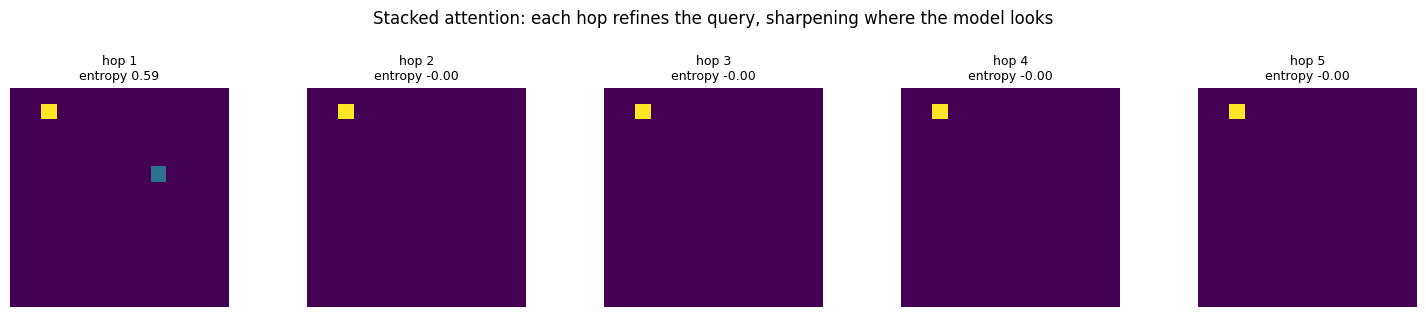

In [12]:
# Static sweep: how many attention hops before the map stops changing?
fig, ax = plt.subplots(1, 5, figsize=(15, 3.0))
u_ = torch.randn(d_feat)
for a_, hop in enumerate(range(5)):
    scores = regions @ u_
    att = torch.softmax(scores, dim=0)
    u_ = att @ regions + u_
    ent = -(att * (att + 1e-12).log()).sum()
    ax[a_].imshow(att.reshape(14, 14), cmap='viridis'); ax[a_].set_axis_off()
    ax[a_].set_title(f'hop {hop + 1}\nentropy {ent:.2f}', fontsize=9)
fig.suptitle('Stacked attention: each hop refines the query, sharpening where the model looks', y=1.04)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [13]:
# Live: number of attention hops, and the effect on where the model ends up looking.
from ipywidgets import interact, IntSlider

def san(hops=2, seed=0):
    torch.manual_seed(seed)
    u_ = torch.randn(d_feat)
    ents = []
    for _ in range(hops):
        att = torch.softmax(regions @ u_, dim=0)
        u_ = att @ regions + u_
        ents.append(-(att * (att + 1e-12).log()).sum().item())
    fig, ax_ = plt.subplots(1, 2, figsize=(9.5, 3.2))
    ax_[0].imshow(att.reshape(14, 14), cmap='viridis'); ax_[0].set_axis_off()
    ax_[0].set_title(f'attention after {hops} hop(s)')
    ax_[1].plot(range(1, hops + 1), ents, 'o-', lw=2)
    ax_[1].set_xlabel('hop'); ax_[1].set_ylabel('entropy (nats)')
    ax_[1].set_title('focus sharpens with each hop')
    plt.tight_layout(); plt.show()

interact(san, hops=IntSlider(min=1, max=8, step=1, value=2),
              seed=IntSlider(min=0, max=10, step=1, value=0));

interactive(children=(IntSlider(value=2, description='hops', max=8, min=1), IntSlider(value=0, description='se…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **VQA** | Image + free-form question → answer; usually posed as classification over the top 1000 answers |
| **Datasets** | VQA (250K images, 750K questions), COCO-QA (auto-generated), Visual7W (7 W's, telling and pointing), CLEVR (reasoning) |
| **Fusion** | Element-wise product (cheap, symmetric), concatenation (asymmetric), full bilinear (~1000× the cost) |
| **SAN** | Attend, add the result back to the query, attend again — focus narrows with each hop |
| **Co-attention** | Attend to the question too, at word, phrase and question level |
| **Visual Dialog** | Image + history + follow-up question → answer |
| **Why ranking** | BLEU/METEOR/ROUGE correlate poorly with human judgement, so rank 100 candidates instead |
| **Baselines** | Random guessing gives mean rank 50.5 and MRR 0.052; beat those before claiming anything |

## Exercises

1. **The homework from the slides.** Are there better ways to evaluate Visual Dialog systems? Consider what the 100-candidate protocol rewards, and construct a model that scores well without understanding the image.
2. **Bilinear, affordably.** Section 2 showed full bilinear fusion costs about 1000× the element-wise product. Look up how compact bilinear pooling reduces this, and work out the cost of a rank-$r$ factorisation for a few values of $r$.
3. **How many hops?** Section 3 stacked two attention layers. Measure the entropy after 1 to 8 hops and find where it stops falling. What does that say about the value of extra hops?
4. **The symmetry problem.** Element-wise product is symmetric in its two inputs. Construct an image and question pair where swapping them ought to change the answer, and say what that implies for the baseline model.
5. **Reconcile the numbers.** The VQA slide states 750K questions, 10 annotators each, and 10M answers. Those do not multiply out. Propose an explanation and say how you would check it against the dataset itself.
